In [1]:
import sys
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gymnasium.envs.classic_control.pendulum import angle_normalize
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# Reuse the dyna_standard environment and dynamics-model registry.
ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "experiments" / "dyna_standard" / "models").exists()
)
DYNA = ROOT / "experiments" / "dyna_standard"
sys.path.insert(0, str(DYNA))

import models
from envs import EnvSpec, collect_rollouts, take_transitions

# Wrap Dynamic Model as Gym Environment

Each dyna_standard dynamics model becomes a Gym environment, PPO trains a policy inside it, and the policy is scored in the real simulator.

`N` is the dynamics model's data budget (the reference's `episodes`): training transitions for a fitted model, context steps for a foundation model. `TOTAL_TIMESTEPS` is the PPO budget (the reference's `time_steps`).

In [2]:
# Bounds are the real reachable sets (MountainCar velocity is +-0.07, CartPole
# terminates at 0.2095 rad), so the model env cannot show the policy states the
# simulator never produces.
ENV_RULES = {
    "Pendulum-v1": dict(
        low=np.array([-1.0, -1.0, -8.0], np.float32),
        high=np.array([1.0, 1.0, 8.0], np.float32),
        horizon=200,
    ),
    "MountainCar-v0": dict(
        low=np.array([-1.2, -0.07], np.float32),
        high=np.array([0.6, 0.07], np.float32),
        horizon=200,
    ),
    "CartPole-v1": dict(
        low=np.array([-4.8, -10.0, -0.418, -10.0], np.float32),
        high=np.array([4.8, 10.0, 0.418, 10.0], np.float32),
        horizon=500,
    ),
}

SHAPED = True
MC_SHAPE = 100.0   # MountainCar speed potential
CP_X_WEIGHT = 1.0  # the reference notebook's value


def reward_of(env_id, prev, action, nxt):
    if env_id == "Pendulum-v1":  # Gymnasium's own, on the state acted from
        theta = np.arctan2(prev[1], prev[0])
        u = float(np.clip(action, -2.0, 2.0))
        return -float(
            angle_normalize(theta) ** 2 + 0.1 * prev[2] ** 2 + 0.001 * u**2
        )
    if not SHAPED:
        return -1.0 if env_id == "MountainCar-v0" else 1.0
    if env_id == "MountainCar-v0":
        # -1 per step plus potential-based shaping on speed, which leaves the
        # optimal policy unchanged. Speed and not position, because the car has
        # to drive away from the goal first to build energy.
        return -1.0 + MC_SHAPE * (abs(nxt[1]) - abs(prev[1]))
    return float(np.cos(nxt[2]) - CP_X_WEIGHT * abs(nxt[0]))  # the reference's


def terminated_of(env_id, obs):
    """Gymnasium's own. Leaving it out makes both returns constant."""
    if env_id == "MountainCar-v0":
        return bool(obs[0] >= 0.5 and obs[1] >= 0.0)
    if env_id == "CartPole-v1":
        return bool(abs(obs[0]) > 2.4 or abs(obs[2]) > 0.2095)
    return False


class ModelEnv(gym.Env):
    """One dyna_standard dynamics model as a Gym environment.

    ``context_len`` is the budget N -- context steps for a foundation model. The
    fitted models ignore it but get the same warm-up, so at a given N the env is
    identical across models.
    """

    def __init__(self, env_id, model, seed=0, context_len=32):
        self.env_id = env_id
        self.dyn_spec = EnvSpec(env_id)
        self.model = model
        self.context_len = int(context_len)
        rules = ENV_RULES[env_id]
        self.horizon = int(rules["horizon"])
        self.low, self.high = rules["low"], rules["high"]
        self.rng = np.random.default_rng(seed)
        base_env = gym.make(env_id)
        self.action_space = base_env.action_space
        base_env.close()
        self.observation_space = gym.spaces.Box(
            self.low, self.high, dtype=np.float32
        )
        mid, half = (self.high + self.low) / 2, (self.high - self.low) / 2
        self.blow_low, self.blow_high = mid - 10 * half, mid + 10 * half
        self.context = self.actions = None
        self.steps = 0

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        seed = int(self.rng.integers(1_000_000)) if seed is None else int(seed)
        data = collect_rollouts(
            self.dyn_spec, 1, seed, episode_len=self.context_len
        )
        # states[1:] pairs with actions[0:]: action i produced state i+1.
        self.context = data["states"][0, 1:].copy()
        self.actions = data["actions"][0].copy()
        self.steps = 0
        return self.context[-1].astype(np.float32), {}

    def step(self, action):
        prev = self.context[-1]
        action = np.asarray(action).reshape(1, 1).astype(np.float32)
        predicted = self.model.predict(
            self.context[None], self.actions[None], action[:, None]
        )[0, 0]
        diverged = (
            not np.isfinite(predicted).all()
            or np.any(predicted < self.blow_low)
            or np.any(predicted > self.blow_high)
        )
        obs = np.clip(
            np.nan_to_num(predicted, nan=0.0, posinf=1e6, neginf=-1e6),
            self.low,
            self.high,
        ).astype(np.float32)
        self.context = np.concatenate([self.context[1:], obs[None]], axis=0)
        self.actions = np.concatenate([self.actions[1:], action], axis=0)
        self.steps += 1
        # Divergence truncates rather than terminates: a terminated state
        # bootstraps with 0, which on negative rewards makes breaking the model
        # the best thing a policy can do.
        return (
            obs,
            reward_of(self.env_id, prev, action[0, 0], obs),
            terminated_of(self.env_id, obs),
            bool(diverged or self.steps >= self.horizon),
            {"diverged": diverged},
        )


TSFM_VARIANTS = {  # (registry name, presentation, stretch r)
    "Chronos-2 S (level)": ("Chronos-2 S (level)", "level", 1),
    "Chronos-2 S (diff, r=6)": ("Chronos-2 S", "diff", 6),
    "Chronos-2 S (diff, r=1)": ("Chronos-2 S", "diff", 1),
}


def make_dynamics(env_id, name, n):
    """The dynamics model at budget N, and the context length its env needs."""
    spec = EnvSpec(env_id)
    if name in TSFM_VARIANTS:
        registry_name, presentation, r = TSFM_VARIANTS[name]
        if not models.fits_context(registry_name, n, r, h=1):
            raise ValueError(f"{name}: N={n} at r={r} overflows the context")
        return models.build(
            registry_name, spec, presentation=presentation, r=r
        ), n
    # One contiguous episode of N steps, as take_transitions delivers at every
    # budget in dyna_standard and as the foundation models get their context.
    # Gluing shorter episodes puts seam rows in the fit and costs ~10x the
    # one-step NMSE at N=1024.
    data = collect_rollouts(spec, 1, seed=100 + n, episode_len=n)
    fit = take_transitions(data, n)
    return models.build(name, spec, lag=1 if name == "MLP" else 4, fit=fit), n

# Instantiate monitored Gym environment

In [ ]:
ENV_IDS = ["CartPole-v1", "MountainCar-v0"]#, "Pendulum-v1"]
N_VALUES = [64, 256, 1024]
MODEL_NAMES = [
    "MLP",
    "VARX",
    "Chronos-2 S (level)",
    "Chronos-2 S (diff, r=6)",
    "Chronos-2 S (diff, r=1)",
]

# N is the dynamics model's data budget (the reference's `episodes`);
# TOTAL_TIMESTEPS is the PPO budget (the reference's `time_steps`), equal for
# every constellation. Chronos runs 51 steps/s at N=64 down to 3.3 at N=1024,
# so the Chronos arm is ~2.9 h per environment at 20k steps.
TOTAL_TIMESTEPS = 20_000
CHECK_FREQ = 1_000
AVG_EPISODES = 30
POLICY_SEEDS = [1, 2]
EVAL_SEEDS = range(20)
MODEL_EVAL_SEEDS = range(3)

RUN_ROOT = ROOT / "experiments" / "dyna_standard_ppo"
LOG_ROOT = RUN_ROOT / "logs"


def run_name(env_id, model_name, n, seed):
    slug = model_name.lower().replace(" ", "_").replace(",", "")
    return f"{env_id}_{slug}_N{n}_s{seed}"


def run_dir(env_id, model_name, n, seed):
    """One directory per run: monitor.csv, best_model.zip, its normalisation."""
    return LOG_ROOT / run_name(env_id, model_name, n, seed)


def make_train_env(env_id, dynamics, context_len, seed, log_dir):
    """The reference's wrapping of CartPoleNNEnv, with ModelEnv in its place.

    ``log_dir=None`` skips the Monitor file, whose writer truncates on open.
    """
    env = ModelEnv(env_id, dynamics, seed=seed, context_len=context_len)
    env = Monitor(env, str(log_dir) if log_dir is not None else None)
    return VecNormalize(DummyVecEnv([lambda: env]), norm_obs=True, norm_reward=True)

# Learn policy

### 1) Callback function for saving best model during training

In [5]:
class SaveOnBestTrainingRewardCallback(BaseCallback):
    """Save the policy whenever the mean training reward improves.

    From the reference notebook. Note what it selects on: reward *inside the
    learned model*, which is the quantity the model can be wrong about.
    """

    def __init__(
        self, check_freq, log_dir, verbose=1, avg_episodes=100, vec_norm_env=None
    ):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = str(log_dir)
        self.save_path = str(Path(log_dir) / "best_model")
        self.best_mean_reward = -np.inf
        self.best_timestep = -np.inf
        self.vec_norm_env = vec_norm_env
        self.avg_episodes = avg_episodes

    def _init_callback(self):
        Path(self.log_dir).mkdir(parents=True, exist_ok=True)

    def _on_step(self):
        if self.n_calls % self.check_freq != 0:
            return True
        x, y = ts2xy(load_results(self.log_dir), "timesteps")
        if len(x) == 0:
            return True
        mean_reward = float(np.mean(y[-self.avg_episodes:]))
        improved = mean_reward > self.best_mean_reward
        if improved:
            self.best_mean_reward = mean_reward
            self.best_timestep = self.num_timesteps
            self.model.save(self.save_path)
            if self.vec_norm_env is not None:
                self.vec_norm_env.save(f"{self.save_path}.env_normalizations")
        if self.verbose > 0:
            print(
                f"   ts {self.num_timesteps:6d} | last {mean_reward:9.2f} | "
                f"best {self.best_mean_reward:9.2f} (ts={self.best_timestep})"
                + ("  <- saved" if improved else ""),
                flush=True,
            )
        return True

### 2) Train Policy

In [5]:
# Training only. Each run writes its log, best policy and normalisation into its
# own directory, so a finished run is skipped and the evaluation cells below can
# be run on their own. PPO is verbose=0; the callback line is the progress.
for env_id in ENV_IDS:
    for n in N_VALUES:
        for model_name in MODEL_NAMES:
            for seed in POLICY_SEEDS:
                log_dir = run_dir(env_id, model_name, n, seed)
                if (log_dir / "done").exists():  # written only after learn() returns
                    print(f"skip (already trained): {log_dir.name}")
                    continue
                print(f"=== {env_id} | {model_name} | N={n} | seed={seed}", flush=True)
                log_dir.mkdir(parents=True, exist_ok=True)
                dynamics, context_len = make_dynamics(env_id, model_name, n)
                env = make_train_env(env_id, dynamics, context_len, seed, log_dir)
                agent = PPO("MlpPolicy", env, verbose=0, seed=seed)
                agent.learn(
                    total_timesteps=TOTAL_TIMESTEPS,
                    callback=SaveOnBestTrainingRewardCallback(
                        check_freq=CHECK_FREQ,
                        log_dir=log_dir,
                        avg_episodes=AVG_EPISODES,
                        vec_norm_env=env,
                    ),
                )
                env.close()
                (log_dir / "done").touch()

=== CartPole-v1 | Chronos-2 S (diff, r=6) | N=1024 | seed=0


Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Plot

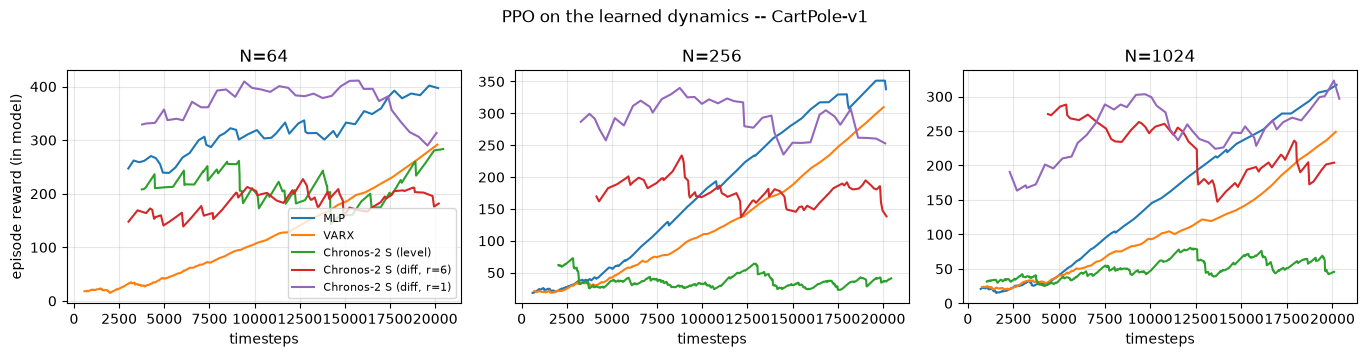

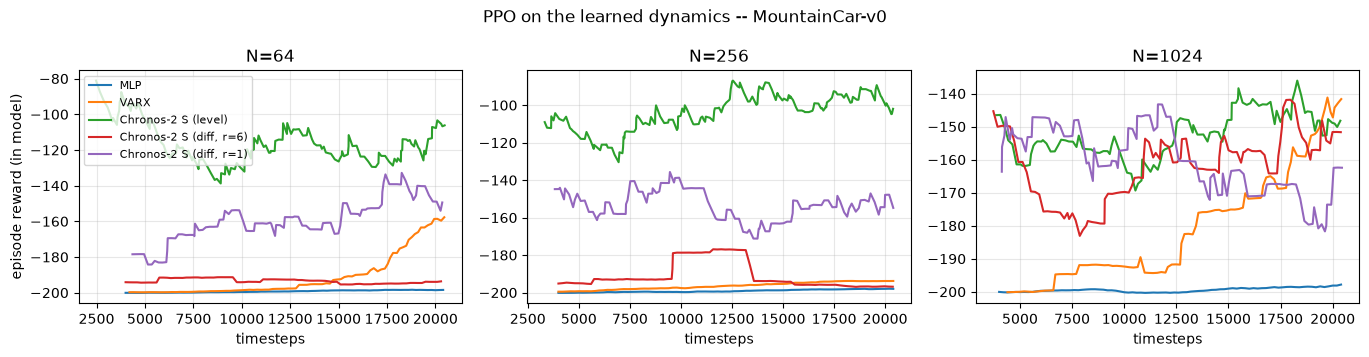

In [6]:
def moving_average(values, window):
    if len(values) < window or window < 2:
        return np.asarray(values, float)
    return np.convolve(np.asarray(values, float), np.ones(window) / window, "valid")


# One figure per environment, one panel per N, one curve per model.
for env_id in ENV_IDS:
    fig, axes = plt.subplots(
        1, len(N_VALUES), figsize=(4.6 * len(N_VALUES), 3.6), squeeze=False
    )
    for col, n in enumerate(N_VALUES):
        ax = axes[0][col]
        for model_name in MODEL_NAMES:
            for seed in POLICY_SEEDS:
                d = run_dir(env_id, model_name, n, seed)
                if not (d / "monitor.csv").exists():
                    continue
                x, y = ts2xy(load_results(str(d)), "timesteps")
                if len(x) == 0:
                    continue
                smooth = moving_average(y, min(AVG_EPISODES, max(1, len(y) // 5)))
                ax.plot(
                    x[len(x) - len(smooth):],
                    smooth,
                    label=model_name if seed == POLICY_SEEDS[0] else None,
                )
        ax.set_title(f"N={n}")
        ax.set_xlabel("timesteps")
        ax.grid(alpha=0.3)
    axes[0][0].set_ylabel("episode reward (in model)")
    axes[0][0].legend(fontsize=8)
    fig.suptitle(f"PPO on the learned dynamics -- {env_id}")
    fig.tight_layout()
    fig.savefig(RUN_ROOT / f"learning_curve_{env_id}.png", dpi=150)
    plt.show()

# Model inference: Evaluate policy

### Load best policy

In [7]:
def load_policy(env_id, model_name, n, seed=0):
    """The saved best policy and the path to its normalisation statistics."""
    d = run_dir(env_id, model_name, n, seed)
    model_path = d / "best_model.zip"
    norm_path = d / "best_model.env_normalizations"
    if not model_path.exists() or not norm_path.exists():
        raise FileNotFoundError(f"No saved policy in {d.name}. Train first.")
    return PPO.load(str(model_path)), norm_path


best_policies = {}
for env_id in ENV_IDS:
    for n in N_VALUES:
        for model_name in MODEL_NAMES:
            for seed in POLICY_SEEDS:
                key = (env_id, model_name, n, seed)
                if (run_dir(*key) / "done").exists():
                    best_policies[key] = load_policy(*key)
print(f"{len(best_policies)} saved policies loaded")

30 saved policies loaded


### Evaluate on environment from where the dynamics data was sampled from

`real_reward` is Gymnasium's own reward in the real simulator -- the headline. `model_reward` is the shaped training reward inside the learned model, and `model_diverged` the fraction of episodes that ended because the model left the reachable set.

In [8]:
def evaluate_real(agent, norm_path, env_id, seeds, render_mode=None):
    """Return of the policy in the real environment -- the headline number.

    The observation of every environment here already is the model observation,
    so the real env is stepped directly, wrapped in the normalisation statistics
    the policy was trained with. ``norm_reward`` is off: a return-normalised
    reward is divided by each run's own ret_rms and is not comparable.
    """
    venv = DummyVecEnv([lambda: gym.make(env_id, render_mode=render_mode)])
    env = VecNormalize.load(str(norm_path), venv)
    env.training = False
    env.norm_reward = False
    rewards, lengths = [], []
    try:
        for seed in seeds:
            env.seed(int(seed))
            state = env.reset()
            total, steps, done = 0.0, 0, False
            while not done:
                action, _ = agent.predict(state, deterministic=True)
                state, reward, dones, _ = env.step(action)
                total += float(reward[0])
                steps += 1
                done = bool(dones[0])
            rewards.append(total)
            lengths.append(steps)
    finally:
        env.close()
    return np.array(rewards), np.array(lengths)


def evaluate_model_env(agent, norm_path, env_id, dynamics, context_len, seeds):
    """Return of the policy inside its own learned dynamics -- the diagnostic.

    Trained on a shaped reward, so this is not on the same scale as
    ``evaluate_real``; what it shows is whether the model is optimistic, and how
    often the policy drives it off the reachable set.
    """
    venv = DummyVecEnv(
        [lambda: ModelEnv(env_id, dynamics, seed=1, context_len=context_len)]
    )
    env = VecNormalize.load(str(norm_path), venv)
    env.training = False
    env.norm_reward = False
    rewards, lengths, diverged = [], [], []
    try:
        for seed in seeds:
            env.seed(int(seed))
            state = env.reset()
            total, steps, done, blew = 0.0, 0, False, False
            while not done:
                action, _ = agent.predict(state, deterministic=True)
                state, reward, dones, infos = env.step(action)
                done = bool(dones[0])
                blew = bool(infos[0].get("diverged", False))
                total += float(reward[0])
                steps += 1
            rewards.append(total)
            lengths.append(steps)
            diverged.append(blew)
    finally:
        env.close()
    return np.array(rewards), np.array(lengths), np.array(diverged)

In [9]:
records = []

for (env_id, model_name, n, seed), (agent, norm_path) in best_policies.items():
    print(f"{env_id} | {model_name} | N={n} | seed={seed}", flush=True)
    real_r, real_l = evaluate_real(agent, norm_path, env_id, EVAL_SEEDS)
    dynamics, context_len = make_dynamics(env_id, model_name, n)
    imag_r, imag_l, imag_d = evaluate_model_env(
        agent, norm_path, env_id, dynamics, context_len, MODEL_EVAL_SEEDS
    )
    records.append(
        {
            "environment": env_id,
            "model": model_name,
            "N": n,
            "seed": seed,
            "real_reward": real_r.mean(),
            "real_reward_std": real_r.std(),
            "real_length": real_l.mean(),
            "real_length_std": real_l.std(),
            "model_reward": imag_r.mean(),
            "model_reward_std": imag_r.std(),
            "model_length": imag_l.mean(),
            "model_diverged": imag_d.mean(),
        }
    )
    print(
        f"   real {real_r.mean():9.2f} +- {real_r.std():6.2f} | "
        f"in-model {imag_r.mean():9.2f} (diverged {imag_d.mean():.0%})",
        flush=True,
    )

results = pd.DataFrame(records)
results.to_csv(RUN_ROOT / "ppo_results.csv", index=False)
results.round(2)

CartPole-v1 | MLP | N=64 | seed=0
   real     39.85 +-   7.07 | in-model    407.58 (diverged 0%)
CartPole-v1 | VARX | N=64 | seed=0
   real    500.00 +-   0.00 | in-model    443.61 (diverged 0%)
CartPole-v1 | Chronos-2 S (level) | N=64 | seed=0


Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

   real     14.70 +-   9.10 | in-model     22.22 (diverged 0%)
CartPole-v1 | Chronos-2 S (diff, r=6) | N=64 | seed=0
   real      9.30 +-   0.64 | in-model    160.80 (diverged 0%)
CartPole-v1 | Chronos-2 S (diff, r=1) | N=64 | seed=0
   real      9.45 +-   0.67 | in-model    264.56 (diverged 0%)
CartPole-v1 | MLP | N=256 | seed=0
   real     80.95 +-  16.63 | in-model    427.67 (diverged 0%)
CartPole-v1 | VARX | N=256 | seed=0
   real    500.00 +-   0.00 | in-model    479.20 (diverged 0%)
CartPole-v1 | Chronos-2 S (level) | N=256 | seed=0
   real    446.15 +- 108.30 | in-model     26.30 (diverged 0%)
CartPole-v1 | Chronos-2 S (diff, r=6) | N=256 | seed=0


KeyboardInterrupt: 

### Results

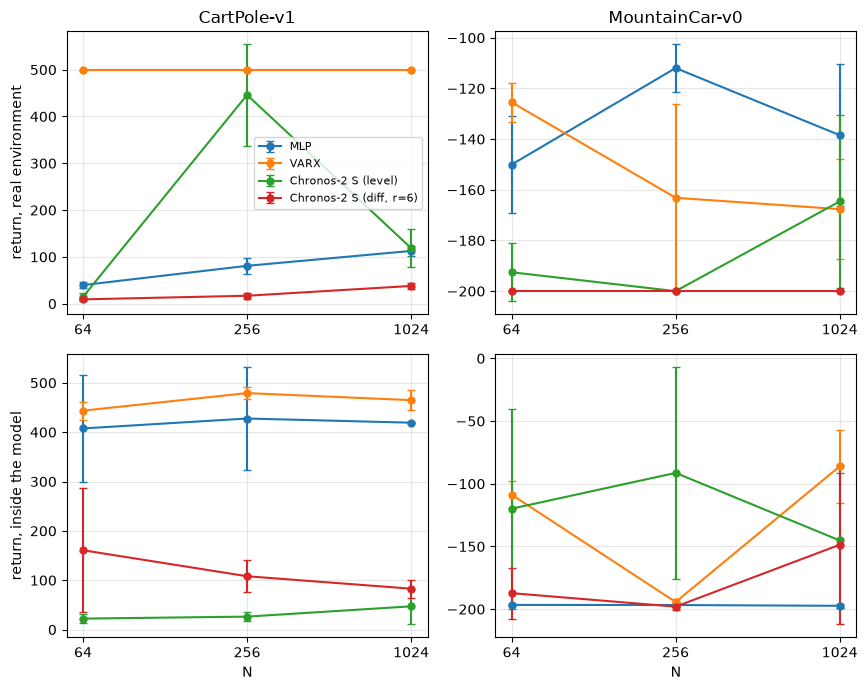

In [18]:
# One panel per environment: the returns live on different scales, so their
# average is not a quantity. Top row is the real environment, bottom row the
# model the policies were trained in.
METRICS = [
    ("real_reward", "real_reward_std", "return, real environment"),
    ("model_reward", "model_reward_std", "return, inside the model"),
]
agg = (
    results.groupby(["environment", "model", "N"])
    .mean(numeric_only=True)
    .reset_index()
)

fig, axes = plt.subplots(
    len(METRICS), len(ENV_IDS),
    figsize=(4.4 * len(ENV_IDS), 3.5 * len(METRICS)), squeeze=False,
)
for row, (metric, err, ylabel) in enumerate(METRICS):
    for col, env_id in enumerate(ENV_IDS):
        ax = axes[row][col]
        sub = agg[agg.environment == env_id]
        for model_name in MODEL_NAMES:
            curve = sub[sub.model == model_name].sort_values("N")
            if curve.empty:
                continue
            ax.errorbar(curve["N"], curve[metric], yerr=curve[err],
                        marker="o", markersize=5, capsize=3, label=model_name)
        ax.set_xscale("log", base=2)
        ax.minorticks_off()
        ax.set_xticks(N_VALUES, labels=[str(v) for v in N_VALUES])
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(env_id)
        if row == len(METRICS) - 1:
            ax.set_xlabel("N")
        if col == 0:
            ax.set_ylabel(ylabel)
axes[0][0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(RUN_ROOT / "ppo_results.png", dpi=150)
plt.show()

## Findings

1. At which N does each model produce policies that transfer to the real environment?
2. Does the foundation model gain from a longer context the way the fitted models gain from more transitions?
3. Does one-step forecast quality (dyna_standard's NMSE at the same N) predict policy quality?